refer `D03`

In [10]:
import crypy as cp
import numpy as np
from matplotlib import pyplot as plt
from crypy_examples.atom_network import (
    draw_atom, 
    draw_bond,
    color_bond,
    color_Se,
    color_Ta,
    r_Se,
    r_Ta,
    r_bond,
    a1,a2,
    p1,p2,p3,p4        
)
from crypy_examples.chiral_interlock import lattice_points_in_hex
from matplotlib.colors import to_rgb

# region Fundamental Parameters
xylim = ((-10,10),(-10,10))

In [46]:
p1

array([0.66666667, 0.33333333])

In [63]:
color_Se_HA = [254,164,0]
color_Ta_HA = [0, 176, 240]
color_hollow = [255, 0, 150]
color_Se_vesta = [202,137,33]
color_Ta_vesta = [38,115,148]
hexer =  lambda rgb: '#{:02x}{:02x}{:02x}'.format(*rgb)

In [ ]:
def draw(pos_CDW,clr_CDW=color_hollow):
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    # gen_bond = lambda x,y: draw_bond(x,y,r=r_bond*.6,facecolor=to_rgb(color_bond))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    print("color_bond rgb:",to_rgb(color_bond))
    # bss.add_artist(gen_bond,(p1,p2),label = 'bond1')
    # bss.add_artist(gen_bond,(p1,p3),label = 'bond2')
    # bss.add_artist(gen_bond,(p2,p4),label = 'bond3')
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(3,3)
    bss_sup = cp.Basis2D(pv_sup)
    def gen_CDW(x,y):    
        ec = np.array(clr_CDW)/255
        ec = np.append(ec,0.6)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=1,fc=(0,0,0,0),ec = ec)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=.3,fc=(0,0,0,0),ec = ec)
    bss_sup.add_artist(gen_CDW,pos_CDW,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    fig,ax  = cry.plot_crystal()
    cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])



color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)
color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)
color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)


<Figure size 640x480 with 0 Axes>

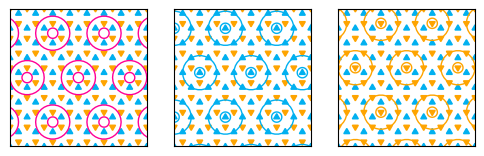

In [65]:
# region plot
plt.figure()
fig,axs = plt.subplots(1,3,figsize=(6,2))
plt.sca(axs[0])
draw(pos_CDW=[0,0],clr_CDW=color_hollow)
plt.sca(axs[1])
draw(pos_CDW=p1/3,clr_CDW=color_Ta_HA)    
plt.sca(axs[2])
draw(pos_CDW=p2/3,clr_CDW=color_Se_HA)    
plt.savefig("D03_CDW_toon2.svg", bbox_inches='tight')